# LangGraph Subgraphs — Shared State Schema

This notebook demonstrates the **shared-schema** pattern for LangGraph subgraphs:
the child graph (`subgraph`) is built directly on the *same* `ParentState`
`TypedDict` that the parent graph uses, so the compiled subgraph can be added
straight into the parent graph as a node — no state-translation wrapper needed.

Flow: `question` → generate an English answer → translate it to Hindi.

**Models (local, via [Ollama](https://ollama.com), no API key required):**
- `llama3.2:3b` — small, fast local model used to generate the initial English answer.
- `gpt-oss:120b-cloud` — larger model (run through Ollama's cloud inference) used for the Hindi translation, where quality matters more.

**Prerequisites:**
1. [Ollama](https://ollama.com) installed and running.
2. Models pulled/available: `ollama pull llama3.2:3b` and `ollama pull gpt-oss:120b-cloud` (the `-cloud` model needs `ollama signin` once, since it runs on Ollama's cloud rather than your machine).
3. Run this notebook using the project's `.venv` kernel (it already has `langchain-ollama`, `langgraph`, etc. installed).

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

In [3]:
class ParentState(TypedDict):

    question: str
    answer_eng: str      #These are State Variables, so we have 3 state variables - question, answer_eng, answer_hin. The question is the input to the graph, and the answers are the outputs of the graph.
    answer_hin: str
    

## Shared state

`ParentState` is used by **both** the parent graph and the subgraph. Because
the schemas are identical, the compiled subgraph can be added directly as a
node in the parent graph — LangGraph just passes the state straight through.

In [4]:
#parent_llm = ChatOllama(model='llama3.2:3b')
parent_llm = ChatOllama(model='gpt-oss:120b-cloud')
subgraph_llm = ChatOllama(model='gpt-oss:120b-cloud')

`parent_llm` (fast, local `llama3.2:3b`) drafts the English answer; `subgraph_llm`
(the bigger `gpt-oss:120b-cloud`) handles the Hindi translation, since
translation quality benefits more from a larger model than the initial draft
does.

In [5]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

**Subgraph node** — reads `answer_eng` from the shared state and writes
`answer_hin` back into it.

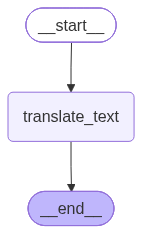

In [6]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

subgraph

**Build & compile the subgraph** on `ParentState` — a single `translate_text`
node from `START` to `END`.

In [7]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

**Parent node** — generates the English answer for the incoming `question`.

In [8]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

**Build the parent graph.** The compiled `subgraph` is added directly as the
`translate` node — this only works because it shares `ParentState` with the
parent graph.

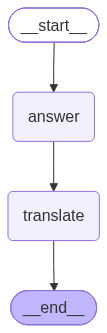

In [9]:
graph = parent_builder.compile()

graph

Compile the parent graph and (in a notebook with Mermaid/graphviz support)
render it.

In [10]:
graph.invoke({'question': 'What is Agentic AI in simple terms?'})

{'question': 'What is Agentic AI in simple terms?',
 'answer_eng': '**Agentic AI in simple terms:**  \n\nIt’s an artificial‑intelligence system that can *act on its own* to achieve a goal, rather than just answering questions or giving recommendations when you ask it to.  \n\nThink of it like a robot “assistant” that has:\n\n1. **A goal or objective** – e.g., “book a flight for me,” “manage my calendar,” or “optimize energy use in a building.”\n2. **The ability to decide what steps to take** – it can figure out, “first check my calendar, then search for flights, then pick the cheapest option.”\n3. **The power to carry out actions** – it can actually click buttons, send emails, turn on a smart‑home device, or trigger other software.\n\nSo, rather than being a passive tool that only replies when you tell it what to do, an *agentic* AI behaves more like an autonomous helper that **plans**, **makes decisions**, and **executes tasks** on its own, all while staying within the limits you set.

In [12]:
graph.invoke({'question': 'How to make papaya sweet pickle?'})

{'question': 'How to make papaya sweet pickle?',
 'answer_eng': '**Papaya Sweet Pickle (Indian‑style “Mithha Achar”)**  \nA bright, tangy‑sweet pickle that’s perfect with rotis, rice, or as a snack. It uses raw (green) papaya, sugar, spices, and a modest amount of vinegar or lemon juice for acidity. The result is a shelf‑stable, mildly sweet pickle that can be enjoyed within a few days and kept for months if stored properly.\n\n---\n\n## Ingredients (makes about 1\u202fkg / 2\u202flb of pickle)\n\n| Item | Amount | Notes |\n|------|--------|-------|\n| Raw green papaya | 1\u202fkg (≈2\u202flb) | Firm, unripe; peeled and cut as described |\n| Salt (non‑iodized) | 2\u202fTbsp (≈30\u202fg) | For drawing out moisture & initial preservation |\n| White sugar (or jaggery) | ½\u202fcup (100\u202fg) | Adjust to taste – more for a sweeter pickle |\n| White vinegar (5\u202f% acidity) | ½\u202fcup (120\u202fml) | Or substitute with fresh lemon juice |\n| Mustard oil (or neutral oil) | ½\u202fcup (

Run the whole graph end-to-end: ask a question in English, get back both the
English answer and its Hindi translation.